In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df['bmi']

0       27.900
1       33.770
2       33.000
3       22.705
4       28.880
         ...  
1333    30.970
1334    31.920
1335    36.850
1336    25.800
1337    29.070
Name: bmi, Length: 1338, dtype: float64

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
duplicates = df[df.duplicated('age',keep=False)]
print(duplicates)
print(df['age'].value_counts())

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]
age
18    69
19    68
50    29
51    29
47    29
46    29
45    29
20    29
48    29
52    29
22    28
49    28
54    28
53    28
21    28
26    28
24    28
25    28
28   

In [21]:
Region_name = df['region'].unique()
Region_name

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [22]:
smoker_count = df[df['smoker'] == 'yes'].groupby('region').size()
print(smoker_count)

region
northeast    67
northwest    58
southeast    91
southwest    58
dtype: int64


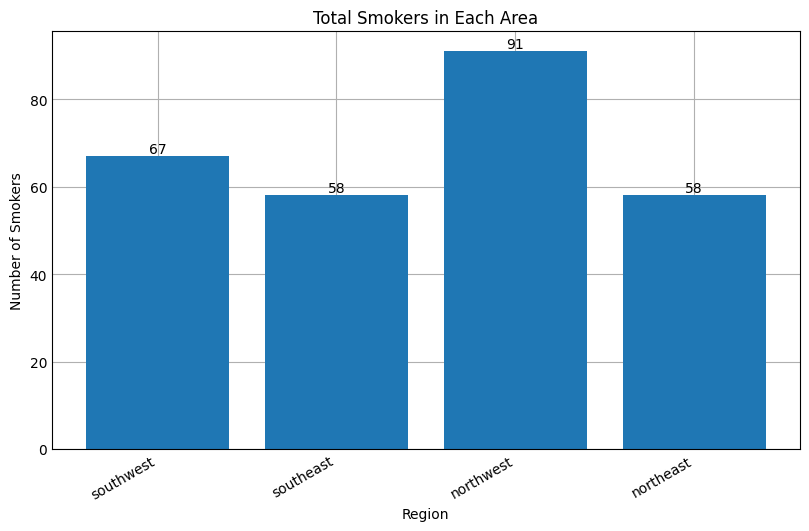

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('_mpl-gallery')

plt.figure(figsize=(8,5))  

x = Region_name
y = smoker_count

bars = plt.bar(x, y)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,   
             height,                             
             f'{int(height)}',                  
             ha='center', va='bottom')

plt.xticks(rotation=30, ha='right')  
plt.tight_layout()

plt.xlabel("Region")
plt.ylabel("Number of Smokers")
plt.title("Total Smokers in Each Area")

plt.show()

In [34]:
grouped = df.groupby(['region','sex'])['smoker'].size().unstack()
print(grouped)

sex        female  male
region                 
northeast     161   163
northwest     164   161
southeast     175   189
southwest     162   163


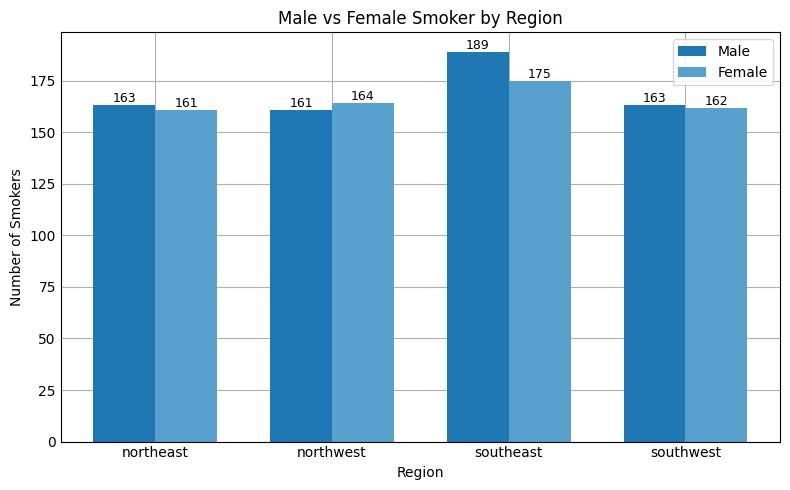

In [36]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('_mpl-gallery')

plt.figure(figsize=(8,5))  

regions = grouped.index
male = grouped['male']
female= grouped['female']

x = np.arange(len(regions))
width = 0.35

bars1 = plt.bar(x - width/2, male,width,label='Male')
bars2 = plt.bar(x + width/2, female,width,label = 'Female')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=9)

plt.xticks(x,regions)
plt.xlabel("Region")
plt.ylabel("Number of Smokers")
plt.title("Male vs Female Smoker by Region")
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
# Normal BMI & Non-Smoker → Fit

# Overweight but Age < 40 & Non-Smoker → Fit

# Underweight & Smoker → Not Fit

# Obese → Not Fit

# Smoker & Age > 50 → Not Fit

# Everything else → Fit

In [37]:
def healthCalculator(age, bmi, smoker):
    
    # BMI Category
    if bmi < 18.5:
        bmi_category = "Underweight"
    elif 18.5 <= bmi <= 24.9:
        bmi_category = "Normal"
    elif 25 <= bmi <= 29.9:
        bmi_category = "Overweight"
    else:
        bmi_category = "Obese"
    
    
    # Health Decision Rules
    if bmi_category == "Normal" and smoker == "No":
        return "Fit"
    
    elif bmi_category == "Overweight" and age < 40 and smoker == "No":
        return "Fit"
    
    elif bmi_category == "Underweight" and smoker == "Yes":
        return "Not Fit"
    
    elif bmi_category == "Obese":
        return "Not Fit"
    
    elif smoker == "Yes" and age > 50:
        return "Not Fit"
    
    else:
        return "Fit"

In [38]:
df['health'] = df.apply(
    lambda row: healthCalculator(row['age'], row['bmi'], row['smoker']),
    axis=1
)

In [39]:
df

,age,sex,bmi,children,smoker,region,charges,health
0,19,female,27.900,0,yes,southwest,16884.92400,Fit
1,18,male,33.770,1,no,southeast,1725.55230,Not Fit
2,28,male,33.000,3,no,southeast,4449.46200,Not Fit
3,33,male,22.705,0,no,northwest,21984.47061,Fit
4,32,male,28.880,0,no,northwest,3866.85520,Fit
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Not Fit
1334,18,female,31.920,0,no,northeast,2205.98080,Not Fit
1335,18,female,36.850,0,no,southeast,1629.83350,Not Fit
1336,21,female,25.800,0,no,southwest,2007.94500,Fit


In [40]:
df['health'].value_counts()

health
Not Fit    719
Fit        619
Name: count, dtype: int64

In [42]:
df['smoker'] = df['smoker'].map({'no' : 0, 'yes': 1})

In [43]:
df

,age,sex,bmi,children,smoker,region,charges,health
0,19,female,27.900,0,1,southwest,16884.92400,Fit
1,18,male,33.770,1,0,southeast,1725.55230,Not Fit
2,28,male,33.000,3,0,southeast,4449.46200,Not Fit
3,33,male,22.705,0,0,northwest,21984.47061,Fit
4,32,male,28.880,0,0,northwest,3866.85520,Fit
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,0,northwest,10600.54830,Not Fit
1334,18,female,31.920,0,0,northeast,2205.98080,Not Fit
1335,18,female,36.850,0,0,southeast,1629.83350,Not Fit
1336,21,female,25.800,0,0,southwest,2007.94500,Fit


In [44]:
df.to_csv("updated_insurance.csv",index = False)

In [45]:
data = pd.read_csv("updated_insurance.csv")

In [46]:
data.head()

,age,sex,bmi,children,smoker,region,charges,health
0,19,female,27.900,0,1,southwest,16884.92400,Fit
1,18,male,33.770,1,0,southeast,1725.55230,Not Fit
2,28,male,33.000,3,0,southeast,4449.46200,Not Fit
3,33,male,22.705,0,0,northwest,21984.47061,Fit
4,32,male,28.880,0,0,northwest,3866.85520,Fit


In [49]:
data['health'] = data['health'].map({'Fit' : 1, 'Not Fit' : 0})

In [50]:
data.head()

,age,sex,bmi,children,smoker,region,charges,health
0,19,female,27.900,0,1,southwest,16884.92400,1
1,18,male,33.770,1,0,southeast,1725.55230,0
2,28,male,33.000,3,0,southeast,4449.46200,0
3,33,male,22.705,0,0,northwest,21984.47061,1
4,32,male,28.880,0,0,northwest,3866.85520,1


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [53]:
X = data[['bmi','age','smoker']]
y = data['health']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
# 6️⃣ Feature Scaling (Important)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [56]:
# 7️⃣ Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [57]:
# 8️⃣ Make Predictions
y_pred = model.predict(X_test)

In [58]:
# 9️⃣ Evaluate Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9888059701492538

Confusion Matrix:
 [[151   2]
 [  1 114]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       153
           1       0.98      0.99      0.99       115

    accuracy                           0.99       268
   macro avg       0.99      0.99      0.99       268
weighted avg       0.99      0.99      0.99       268



In [64]:
import numpy as np

# New person data
#bmi,age,smoker in below array
new_data = np.array([[30, 28, 1]])

# Scale the data (VERY IMPORTANT - use same scaler)
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = model.predict(new_data_scaled)

# Print result
if prediction[0] == 1:
    print("The person is FIT")
else:
    print("The person is NOT FIT")

The person is NOT FIT


c:\Users\Deepak\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
